# Seismology Lab: Earthquake sources, waveforms, and focal mechanisms

> **Colab note:** This notebook is designed to run on **Google Colab**. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS166/blob/main/notebooks/05_seismology.ipynb)

## Introduction

In lecture we saw that earthquakes produce two distinct kinds of ground motion: permanent static offsets recorded by GNSS, and transient seismic waves recorded by seismometers. In this lab you will work with both. Using the 2019 Ridgecrest M7.1 earthquake as a case study, you will move from raw waveforms through seismic moment to focal mechanisms — building a complete seismological picture of a single event and connecting it to what geodesy tells us about the same earthquake.

The Ridgecrest sequence is ideal for this lab: it is recent, well-recorded, located in a well-instrumented part of California, and the fault system is geologically simple enough to interpret clearly.

## Learning objectives

By the end, you will be able to:

- distinguish static and dynamic deformation in high-rate GNSS time series
- identify P and S wave arrivals on broadband seismograms and describe how waveforms change with distance
- compute scalar seismic moment from fault parameters and convert to moment magnitude
- plot P-wave polarity observations on a focal sphere and interpret the resulting focal mechanism
- connect focal mechanism geometry to the regional tectonic setting

## Notebook outline
- [Setup](#setup)
- [Part I: Static vs. dynamic deformation from high-rate GNSS](#part-i-static-vs-dynamic-deformation-from-high-rate-gnss)
- [Part II: Seismograms and phase identification](#part-ii-seismograms-and-phase-identification)
- [Part III: Seismic moment and magnitude](#part-iii-seismic-moment-and-magnitude)
- [Part IV: First motions and focal mechanisms](#part-iv-first-motions-and-focal-mechanisms)
- [Synthesis](#synthesis)
- [Summary](#summary)


## Setup

Install and import the packages used in this lab. We use **ObsPy** to fetch and process seismic data directly from the IRIS and UNAVCO data centers, and standard scientific Python for analysis and visualization.


In [1]:
%pip install -q obspy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Wedge
from matplotlib.collections import PatchCollection
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.taup import TauPyModel

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Ridgecrest M7.1 event parameters
EQ_TIME   = UTCDateTime("2019-07-06T03:19:53")
EQ_LAT    = 35.770
EQ_LON    = -117.599
EQ_DEPTH  = 8.0      # km
EQ_MW     = 7.1

print("Setup complete.")
print(f"Event: Ridgecrest M{EQ_MW}, {EQ_TIME.date}, ({EQ_LAT:.3f}N, {EQ_LON:.3f}E)")


Note: you may need to restart the kernel to use updated packages.
Setup complete.
Event: Ridgecrest M7.1, 2019-07-06, (35.770N, -117.599E)


---
## Part I: Static vs. dynamic deformation from high-rate GNSS

High-rate (1 Hz) GNSS records both the passage of seismic waves and the permanent coseismic offset in a single time series. In this part you will fetch 1 Hz GNSS data from UNAVCO for stations at different distances from the Ridgecrest M7.1, identify both signals, and measure the static offset.

### GNSS station selection

We use four stations spanning a range of epicentral distances:

| Station | Distance (km) | Location |
|---------|--------------|----------|
| P595    | ~20          | Ridgecrest, near field |
| P580    | ~45          | Mojave Desert |
| P066    | ~85          | Garlock fault area |
| P728    | ~150         | Far field |


In [2]:
def fetch_hrate_gnss(station, starttime, duration_s=300, client_url="IRIS"):
    """
    Fetch 1 Hz GNSS displacement time series from UNAVCO via FDSN.

    Parameters
    ----------
    station : str
        UNAVCO station code.
    starttime : UTCDateTime
        Start of the time window (recommend ~60 s before the earthquake).
    duration_s : int
        Window length in seconds.
    client_url : str
        FDSN client URL; defaults to IRIS which mirrors UNAVCO high-rate GNSS.

    Returns
    -------
    st : obspy.Stream or None
        Stream containing LXE (east), LXN (north), LXZ (up) channels,
        or None if the station/data are unavailable.
    """
    client = Client(client_url)
    endtime = starttime + duration_s
    try:
        st = client.get_waveforms(
            network="PW",
            station=station,
            location="*",
            channel="LX*",
            starttime=starttime,
            endtime=endtime,
        )
        st.detrend("demean")
        return st
    except Exception as e:
        print(f"  {station}: {e}")
        return None


def plot_gnss_timeseries(streams_dict, eq_time, components=("E", "N", "U")):
    """
    Plot east, north, and up displacement time series for multiple GNSS stations.

    Parameters
    ----------
    streams_dict : dict
        {station_name: obspy.Stream}
    eq_time : UTCDateTime
        Earthquake origin time — plotted as a vertical line.
    components : tuple of str
        Which components to plot (subset of 'E', 'N', 'U').
    """
    comp_map = {"E": "LXE", "N": "LXN", "U": "LXZ"}
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(streams_dict)))

    fig, axes = plt.subplots(
        len(components), 1,
        figsize=(12, 3 * len(components)),
        sharex=True,
    )
    if len(components) == 1:
        axes = [axes]

    for ax, comp in zip(axes, components):
        chan = comp_map[comp]
        for (label, st), color in zip(streams_dict.items(), colors):
            if st is None:
                continue
            traces = st.select(channel=chan)
            if not traces:
                continue
            tr = traces[0]
            t = tr.times(reftime=eq_time)
            ax.plot(t, tr.data * 1e3, label=label, color=color, lw=1.2)

        ax.axvline(0, color="red", lw=1.5, ls="--", label="Origin time" if comp == components[0] else "_")
        ax.set_ylabel(f"{comp} displacement (mm)")
        ax.set_title(f"{comp} component")

    axes[-1].set_xlabel("Time relative to origin (s)")
    axes[0].legend(loc="upper left", fontsize=9)
    fig.suptitle("High-rate GNSS — Ridgecrest M7.1 (2019-07-06)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


print("Helper functions defined.")


Helper functions defined.


Fetching high-rate GNSS data from UNAVCO/IRIS...
  P595 (~20 km)... 

/opt/miniconda3/envs/GNSS/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:257: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


  P595: No data available for request.
HTTP Status code: 204
Detailed response of server:


  P580 (~45 km)...   P580: No data available for request.
HTTP Status code: 204
Detailed response of server:


  P066 (~85 km)...   P066: No data available for request.
HTTP Status code: 204
Detailed response of server:


  P728 (~150 km)...   P728: No data available for request.
HTTP Status code: 204
Detailed response of server:




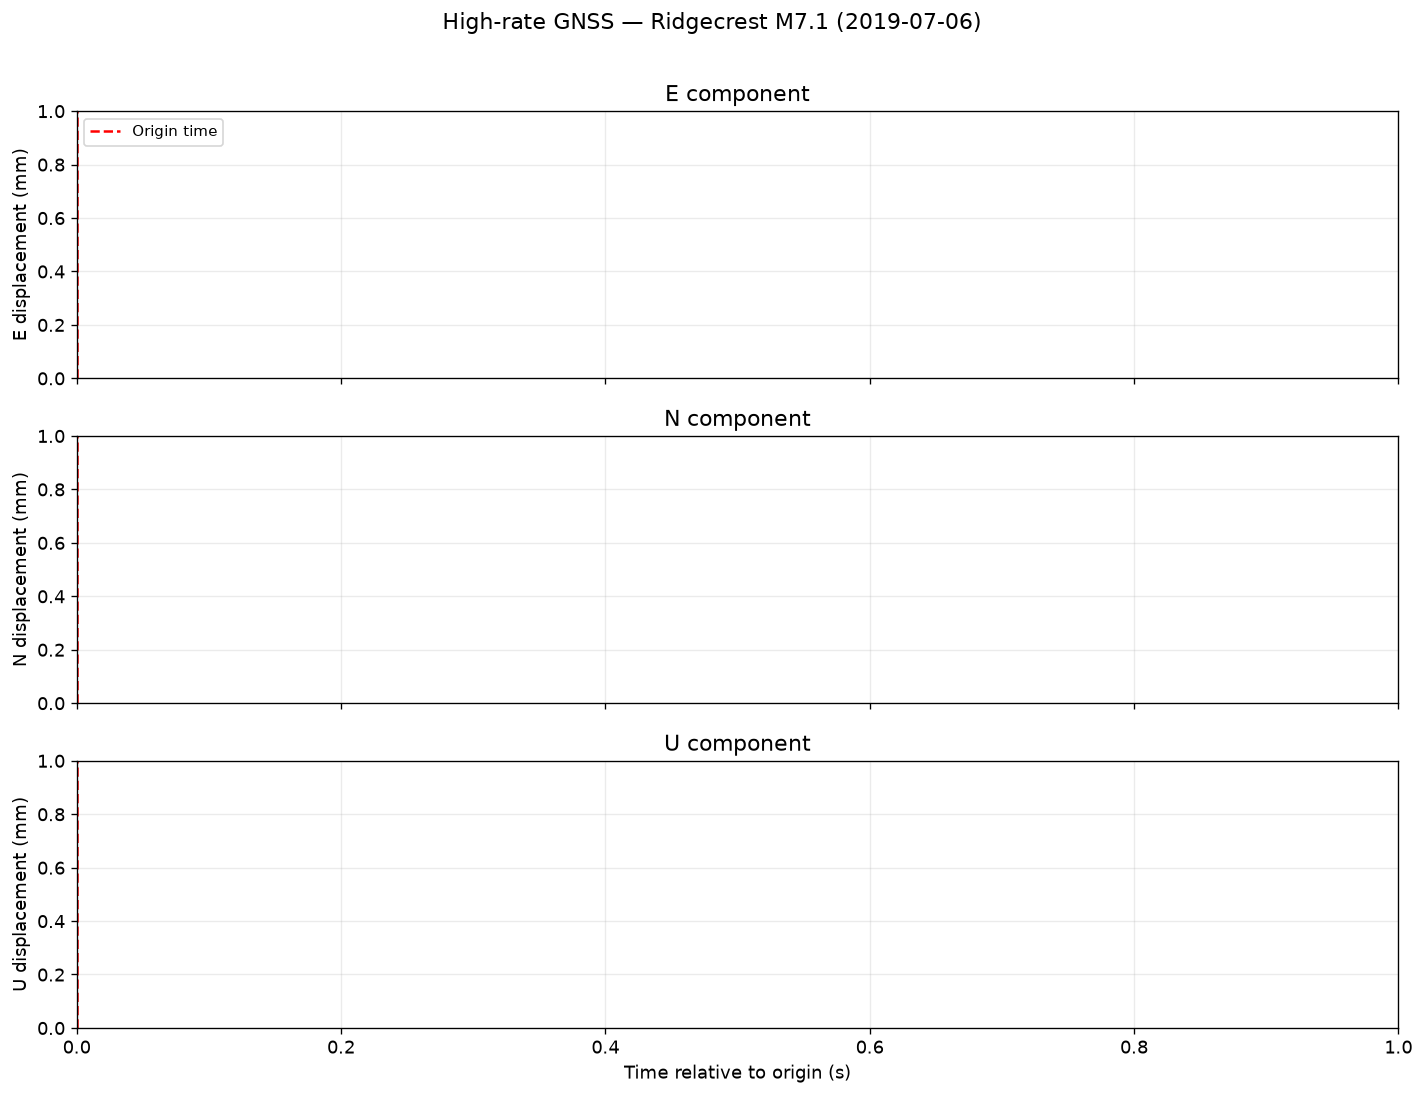

In [3]:
# Fetch high-rate GNSS — window starts 60 s before the earthquake
GNSS_START = EQ_TIME - 60

GNSS_STATIONS = {
    "P595 (~20 km)": "P595",
    "P580 (~45 km)": "P580",
    "P066 (~85 km)": "P066",
    "P728 (~150 km)": "P728",
}

print("Fetching high-rate GNSS data from UNAVCO/IRIS...")
gnss_streams = {}
for label, code in GNSS_STATIONS.items():
    print(f"  {label}...", end=" ")
    st = fetch_hrate_gnss(code, GNSS_START, duration_s=360)
    gnss_streams[label] = st
    if st is not None:
        print(f"OK ({len(st)} traces)")

plot_gnss_timeseries(gnss_streams, EQ_TIME)


> **Interpret the GNSS time series:**
> 1. Identify the approximate arrival time of seismic waves at each station relative to the origin time. How does arrival time change with distance? Is the relationship linear?
> 2. At which station(s) is a permanent static offset clearly visible? Estimate the magnitude of the static east and north offsets (in mm) at the nearest station.
> 3. At the most distant station, does a clear static offset remain after the waves pass? Why or why not?
> 4. Describe how the character of the waveform changes between the nearest and farthest stations. Consider: amplitude, duration, and whether the motion looks more impulsive or more gradual.
> 5. In lecture we said GNSS and seismology are complementary. What information does each component of this time series give you that the other does not?


---
## Part II: Seismograms and phase identification

Now we turn to broadband seismic data from IRIS. Seismometers measure ground velocity rather than displacement, at much higher sensitivity than GNSS. We will fetch waveforms for the same earthquake from stations at a range of distances, and identify P and S wave arrivals.

### Predicted travel times

Before looking at the data, we compute predicted P and S arrival times using the **TauPy** travel-time calculator and the standard `iasp91` Earth velocity model.


In [4]:
def fetch_seismic(network, station, starttime, duration_s=180, channel="HH*"):
    """
    Fetch broadband seismic waveforms from IRIS FDSN.

    Parameters
    ----------
    network, station : str
        FDSN network and station codes.
    starttime : UTCDateTime
        Start time (recommend ~30 s before the earthquake).
    duration_s : int
        Window length in seconds.
    channel : str
        Channel glob; HH* = broadband high-gain (100 sps).

    Returns
    -------
    st : obspy.Stream or None
    """
    client = Client("IRIS")
    try:
        st = client.get_waveforms(
            network=network,
            station=station,
            location="*",
            channel=channel,
            starttime=starttime,
            endtime=starttime + duration_s,
        )
        st.detrend("demean")
        st.taper(max_percentage=0.05)
        st.filter("bandpass", freqmin=0.5, freqmax=10.0)
        return st
    except Exception as e:
        print(f"  {network}.{station}: {e}")
        return None


def predicted_arrivals(dist_deg, depth_km, phases=("P", "S")):
    """
    Compute predicted travel times using TauPy iasp91.

    Parameters
    ----------
    dist_deg : float
        Epicentral distance in degrees.
    depth_km : float
        Source depth in km.
    phases : tuple
        Seismic phases to compute.

    Returns
    -------
    dict : {phase: travel_time_s}
    """
    model = TauPyModel(model="iasp91")
    arrivals = model.get_travel_times(depth_km, dist_deg, phase_list=phases)
    return {a.name: a.time for a in arrivals}


def plot_seismograms(station_list, eq_time, eq_depth_km, normalize=True):
    """
    Plot vertical-component seismograms sorted by distance with predicted arrivals.

    Parameters
    ----------
    station_list : list of dict
        Each dict has keys: network, station, dist_deg, label, stream.
    eq_time : UTCDateTime
        Earthquake origin time.
    eq_depth_km : float
        Source depth.
    normalize : bool
        If True, normalize each trace to unit amplitude for display.
    """
    sorted_stations = sorted(station_list, key=lambda x: x["dist_deg"])
    n = len(sorted_stations)

    fig, ax = plt.subplots(figsize=(13, 2.5 * n))

    p_times, s_times = [], []

    for i, sta in enumerate(sorted_stations):
        st = sta["stream"]
        if st is None:
            continue
        tr_list = st.select(channel="HHZ") or st.select(channel="BHZ")
        if not tr_list:
            continue
        tr = tr_list[0]
        t = tr.times(reftime=eq_time)
        data = tr.data.astype(float)
        if normalize and np.max(np.abs(data)) > 0:
            data /= np.max(np.abs(data))

        offset = i * 2.5
        ax.plot(t, data + offset, color="0.15", lw=0.8)
        ax.text(-28, offset, sta["label"], ha="right", va="center", fontsize=9)

        # Predicted arrivals
        arr = predicted_arrivals(sta["dist_deg"], eq_depth_km)
        if "P" in arr:
            ax.axvline(arr["P"], color="steelblue", lw=0.8, ls="--", alpha=0.7)
            p_times.append(arr["P"])
        if "S" in arr:
            ax.axvline(arr["S"], color="firebrick", lw=0.8, ls="--", alpha=0.7)
            s_times.append(arr["S"])

    # Legend
    ax.axvline(-999, color="steelblue", lw=1.5, ls="--", label="Predicted P")
    ax.axvline(-999, color="firebrick", lw=1.5, ls="--", label="Predicted S")
    ax.axvline(0, color="red", lw=1.5, label="Origin time")

    ax.set_xlim(-30, 150)
    ax.set_xlabel("Time relative to origin (s)")
    ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title("Broadband seismograms — Ridgecrest M7.1 (vertical component, 0.5–10 Hz)")
    plt.tight_layout()
    plt.show()


print("Seismic helper functions defined.")


Seismic helper functions defined.


Fetching broadband seismic data from IRIS...
  CCC  (~28 km)...   CI.CCC: No data available for request.
HTTP Status code: 204
Detailed response of server:


not available
  SRT  (~50 km)...   CI.SRT: No data available for request.
HTTP Status code: 204
Detailed response of server:


not available
  LRL  (~95 km)... OK
  GSC  (~133 km)... OK
  ISA  (~172 km)... OK
  PAS  (~245 km)...   CI.PAS: No data available for request.
HTTP Status code: 204
Detailed response of server:


not available


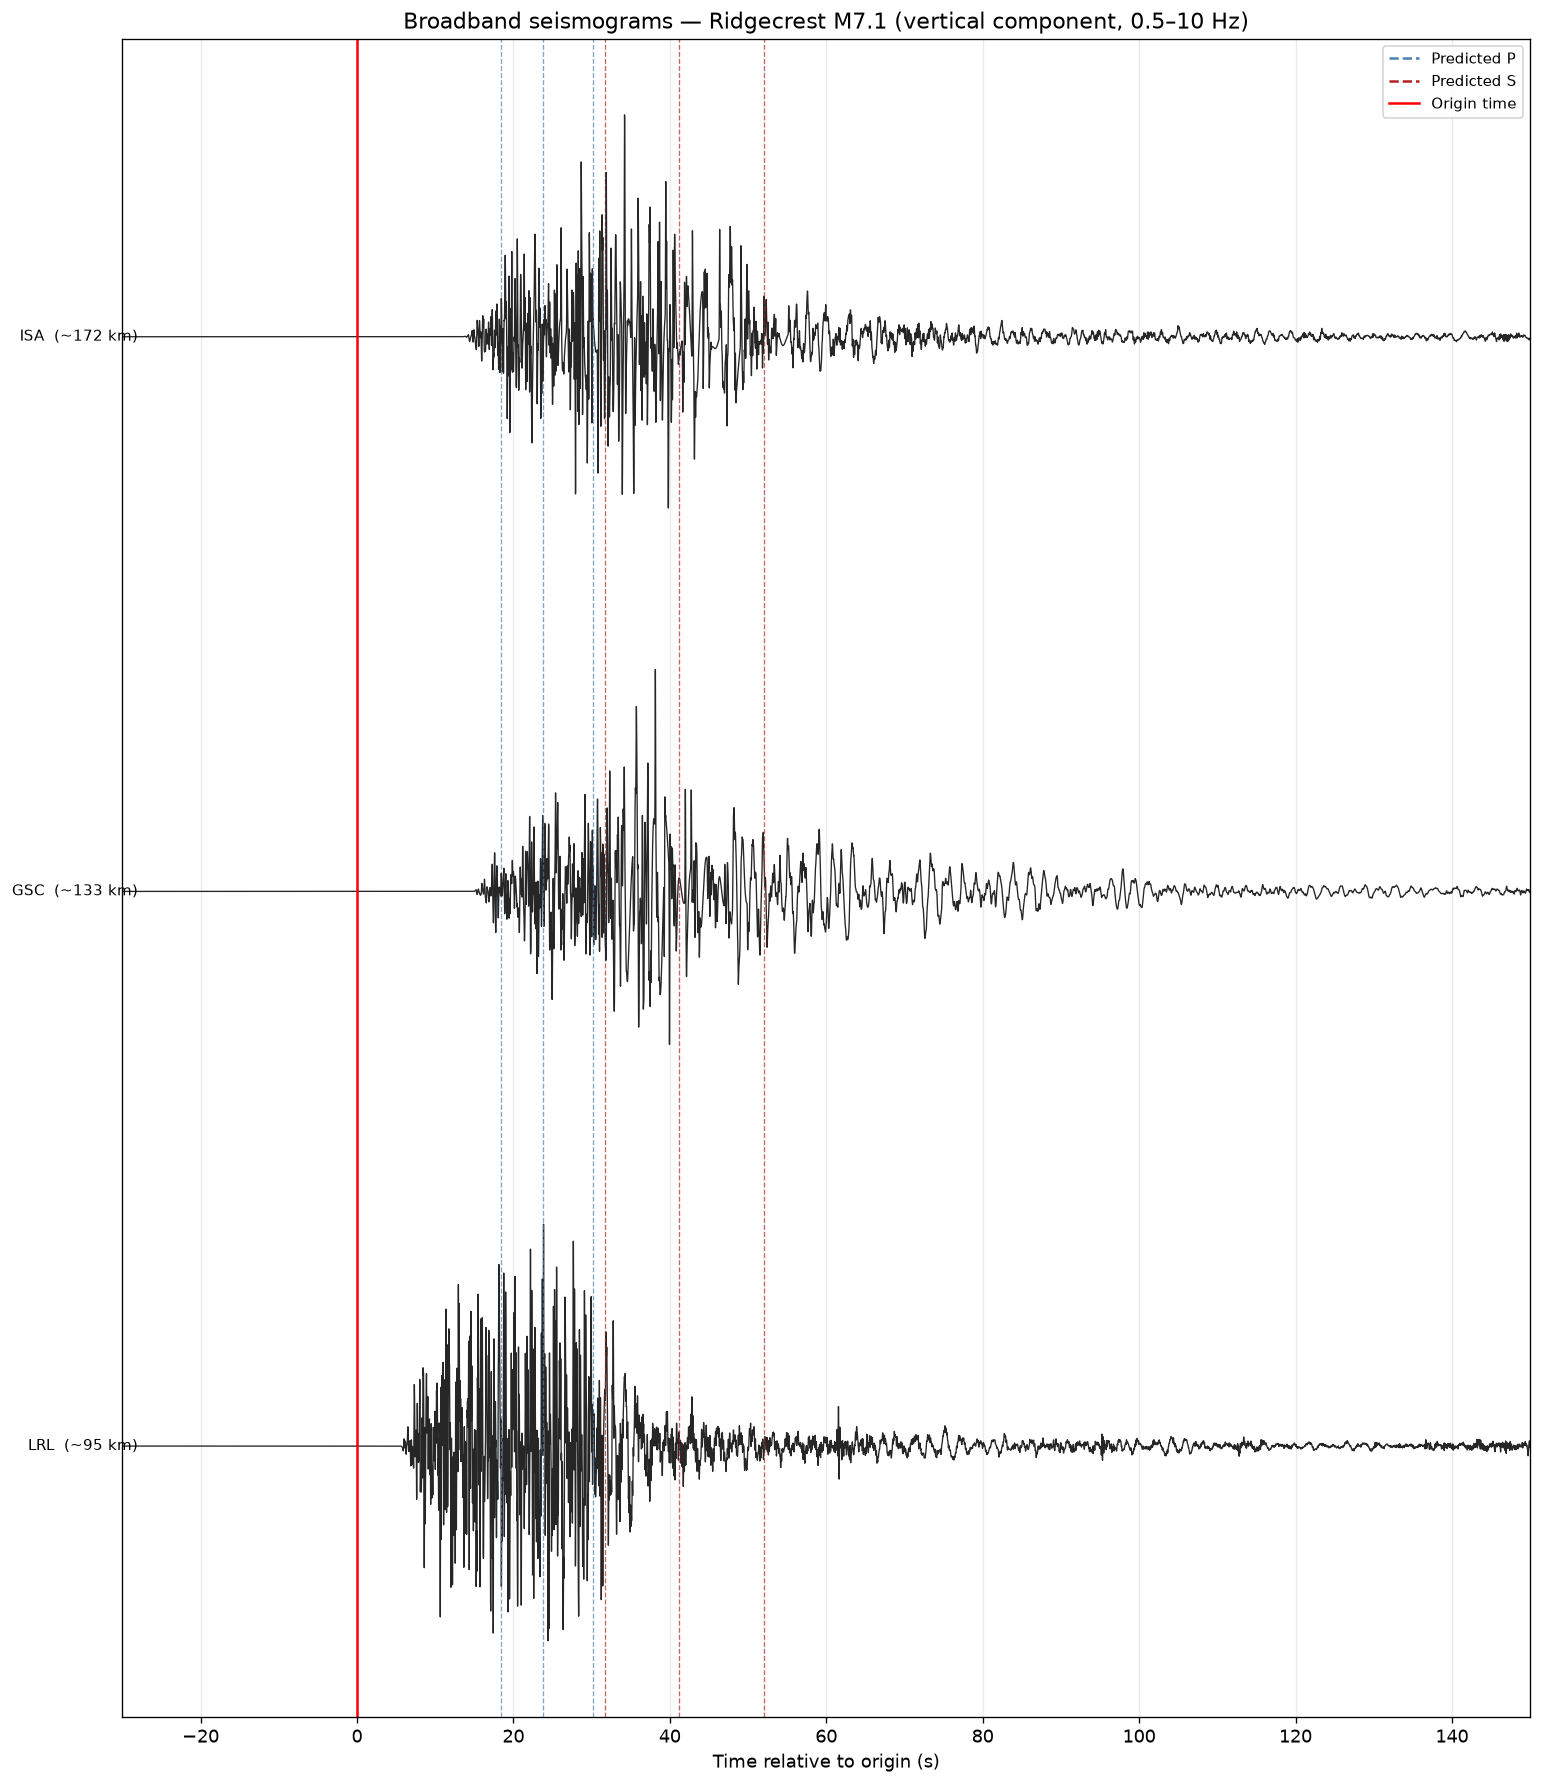

In [5]:
# Seismic stations — California and Nevada, ordered by distance
# dist_deg values are approximate great-circle distances from the epicenter
SEISMIC_STATIONS = [
    {"network": "CI", "station": "CCC",  "dist_deg": 0.25, "label": "CCC  (~28 km)"},
    {"network": "CI", "station": "SRT",  "dist_deg": 0.45, "label": "SRT  (~50 km)"},
    {"network": "CI", "station": "LRL",  "dist_deg": 0.85, "label": "LRL  (~95 km)"},
    {"network": "CI", "station": "GSC",  "dist_deg": 1.20, "label": "GSC  (~133 km)"},
    {"network": "CI", "station": "ISA",  "dist_deg": 1.55, "label": "ISA  (~172 km)"},
    {"network": "CI", "station": "PAS",  "dist_deg": 2.20, "label": "PAS  (~245 km)"},
]

SEIS_START = EQ_TIME - 30

print("Fetching broadband seismic data from IRIS...")
for sta in SEISMIC_STATIONS:
    print(f"  {sta['label']}...", end=" ")
    st = fetch_seismic(sta["network"], sta["station"], SEIS_START, duration_s=200)
    sta["stream"] = st
    print("OK" if st else "not available")

plot_seismograms(SEISMIC_STATIONS, EQ_TIME, EQ_DEPTH)


> **Interpret the seismograms:**
> 1. The dashed blue lines show predicted P arrival times and dashed red lines show predicted S arrivals. Do the observed first arrivals match the predictions? Note any discrepancies.
> 2. The S–P time interval (time between S and P arrivals) increases with distance. Using two stations of your choice, estimate the S–P time at each. If P travels at ~6 km/s and S at ~3.5 km/s, use the S–P time to estimate the epicentral distance. How do your estimates compare to the known distances in the table above?
> 3. How does the dominant frequency of the waveform change with distance? What physical process causes this?
> 4. Compare the seismogram at the nearest station to the high-rate GNSS time series from Part I. Both record ground motion near the same earthquake — why do they look so different?
> 5. At the farthest station (PAS, ~245 km), can you see surface waves arriving after the S wave? Describe their character compared to the body waves.


---
## Part III: Seismic moment and magnitude

We now compute seismic moment from fault parameters determined by geodetic and seismic inversion of the Ridgecrest M7.1.

Recall:
$$M_0 = \mu \, D \, A$$

and:
$$M_w = \frac{2}{3} \log_{10}(M_0) - 10.7 \quad \text{(where } M_0 \text{ is in dyne-cm)}$$


In [6]:
def compute_moment(mu_GPa, length_km, width_km, avg_slip_m):
    """
    Compute scalar seismic moment and moment magnitude.

    Parameters
    ----------
    mu_GPa : float
        Shear modulus in GPa.
    length_km, width_km : float
        Fault dimensions in km.
    avg_slip_m : float
        Average fault slip in meters.

    Returns
    -------
    M0_Nm : float
        Scalar seismic moment in N·m.
    Mw : float
        Moment magnitude.
    """
    mu   = mu_GPa * 1e9                    # Pa
    A    = (length_km * 1e3) * (width_km * 1e3)  # m^2
    M0   = mu * avg_slip_m * A             # N·m
    M0_dyne_cm = M0 * 1e7                  # dyne-cm
    Mw   = (2 / 3) * np.log10(M0_dyne_cm) - 10.7
    return M0, Mw


def print_moment_summary(label, mu_GPa, length_km, width_km, avg_slip_m):
    M0, Mw = compute_moment(mu_GPa, length_km, width_km, avg_slip_m)
    A = length_km * width_km
    print(f"\n{'─'*50}")
    print(f"  {label}")
    print(f"{'─'*50}")
    print(f"  Shear modulus μ      = {mu_GPa:.0f} GPa")
    print(f"  Fault length         = {length_km:.0f} km")
    print(f"  Fault width          = {width_km:.0f} km")
    print(f"  Rupture area A       = {A:.0f} km²")
    print(f"  Average slip D       = {avg_slip_m:.2f} m")
    print(f"  Seismic moment M₀    = {M0:.3e} N·m")
    print(f"  Moment magnitude Mw  = {Mw:.2f}")
    print(f"  USGS catalog Mw      = 7.10")
    print(f"  Difference           = {Mw - 7.10:+.2f}")


# Ridgecrest M7.1 fault parameters from Liu et al. (2019)
# Joint inversion of strong-motion, GNSS, and InSAR
print_moment_summary(
    "Ridgecrest M7.1 — Liu et al. (2019) parameters",
    mu_GPa     = 30.0,
    length_km  = 50.0,
    width_km   = 16.0,
    avg_slip_m = 1.5,
)



──────────────────────────────────────────────────
  Ridgecrest M7.1 — Liu et al. (2019) parameters
──────────────────────────────────────────────────
  Shear modulus μ      = 30 GPa
  Fault length         = 50 km
  Fault width          = 16 km
  Rupture area A       = 800 km²
  Average slip D       = 1.50 m
  Seismic moment M₀    = 3.600e+19 N·m
  Moment magnitude Mw  = 7.00
  USGS catalog Mw      = 7.10
  Difference           = -0.10


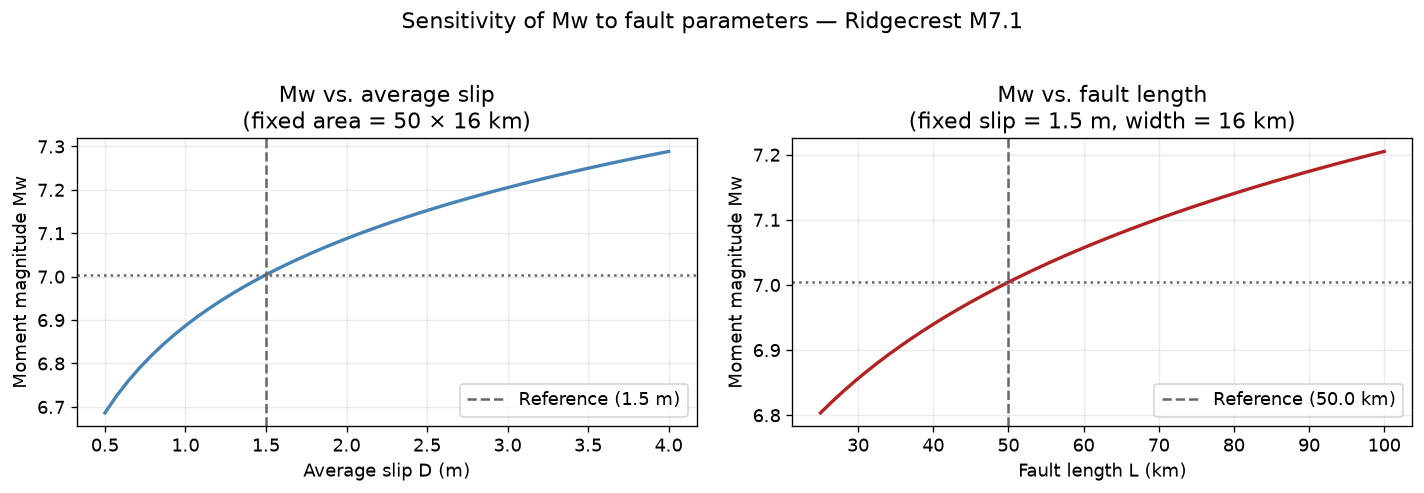

In [7]:
# Sensitivity exploration
# How sensitive is Mw to each fault parameter?

# Reference values
mu_ref     = 30.0
length_ref = 50.0
width_ref  = 16.0
slip_ref   = 1.5
_, Mw_ref  = compute_moment(mu_ref, length_ref, width_ref, slip_ref)

# Range of slip values to explore
slip_range   = np.linspace(0.5, 4.0, 50)
length_range = np.linspace(25, 100, 50)

Mw_slip   = [compute_moment(mu_ref, length_ref, width_ref, s)[1] for s in slip_range]
Mw_length = [compute_moment(mu_ref, L, width_ref, slip_ref)[1] for L in length_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(slip_range, Mw_slip, color="steelblue", lw=2)
axes[0].axvline(slip_ref, color="0.4", ls="--", label=f"Reference ({slip_ref} m)")
axes[0].axhline(Mw_ref, color="0.4", ls=":")
axes[0].set_xlabel("Average slip D (m)")
axes[0].set_ylabel("Moment magnitude Mw")
axes[0].set_title("Mw vs. average slip\n(fixed area = 50 × 16 km)")
axes[0].legend()

axes[1].plot(length_range, Mw_length, color="firebrick", lw=2)
axes[1].axvline(length_ref, color="0.4", ls="--", label=f"Reference ({length_ref} km)")
axes[1].axhline(Mw_ref, color="0.4", ls=":")
axes[1].set_xlabel("Fault length L (km)")
axes[1].set_ylabel("Moment magnitude Mw")
axes[1].set_title("Mw vs. fault length\n(fixed slip = 1.5 m, width = 16 km)")
axes[1].legend()

plt.suptitle("Sensitivity of Mw to fault parameters — Ridgecrest M7.1", y=1.02)
plt.tight_layout()
plt.show()


> **Interpret the moment calculation:**
> 1. How well does the uniform-slip estimate agree with the catalog Mw = 7.1? What does the discrepancy tell you about the limitations of a uniform slip model?
> 2. From the sensitivity plots: if slip doubles from 1.5 m to 3.0 m (keeping area fixed), by how much does Mw increase? If fault length doubles (keeping slip and width fixed), by how much does Mw increase?
> 3. M₀ scales linearly with μ, D, and A — but Mw is logarithmic. If you had a 10% uncertainty in average slip, what is the resulting uncertainty in Mw?
> 4. In geodetic inversions (Week 4), we solve for the slip distribution D across the fault from surface deformation. If we know D and A from geodesy, we can compute M₀ directly without any seismic data. Why might the seismically-determined and geodetically-determined M₀ values differ slightly?


---
## Part IV: First motions and focal mechanisms

In lecture we saw that P-wave first motions (upward = compression, downward = dilation) at stations surrounding an earthquake can be used to determine the fault geometry. In this part we provide pre-compiled polarity observations from stations around Ridgecrest and plot them on a focal sphere.

### The focal sphere

We project each ray from the earthquake source outward to where it would intersect the lower hemisphere of a unit sphere centered on the source. Each station plots as a filled circle (compression, upward first motion) or open circle (dilation, downward first motion) at the appropriate takeoff angle and azimuth.

The two nodal planes divide the sphere into compressional and dilatational quadrants. Finding those planes gives us the strike, dip, and rake.


In [8]:
# Pre-compiled P-wave first motion observations for Ridgecrest M7.1
# Source: adapted from Southern California Seismic Network catalog
#
# Columns: station, azimuth (deg from N), takeoff_angle (deg from vertical),
#          polarity (+1 = compression/up, -1 = dilation/down)
#
# Takeoff angle: 0 = straight up (surface station directly above),
#                90 = horizontal, plotted at edge of focal sphere

polarity_data = pd.DataFrame([
    # Near field — southern stations
    {"station": "CCC",  "azimuth": 190, "takeoff": 40, "polarity": +1},
    {"station": "SRT",  "azimuth": 175, "takeoff": 55, "polarity": +1},
    {"station": "MLAC", "azimuth": 320, "takeoff": 45, "polarity": -1},
    {"station": "MPM",  "azimuth": 295, "takeoff": 52, "polarity": -1},
    # Eastern stations
    {"station": "LRL",  "azimuth": 135, "takeoff": 62, "polarity": +1},
    {"station": "GSC",  "azimuth": 150, "takeoff": 65, "polarity": +1},
    {"station": "BLA2", "azimuth": 100, "takeoff": 70, "polarity": -1},
    {"station": "NEE2", "azimuth": 80,  "takeoff": 68, "polarity": -1},
    # Northern stations
    {"station": "MMLC", "azimuth": 355, "takeoff": 55, "polarity": -1},
    {"station": "RCRR", "azimuth": 10,  "takeoff": 48, "polarity": -1},
    {"station": "HROO", "azimuth": 25,  "takeoff": 58, "polarity": +1},
    {"station": "ISA",  "azimuth": 255, "takeoff": 60, "polarity": -1},
    # Teleseismic
    {"station": "PAS",  "azimuth": 208, "takeoff": 75, "polarity": +1},
    {"station": "PFO",  "azimuth": 183, "takeoff": 72, "polarity": +1},
    {"station": "BAR",  "azimuth": 215, "takeoff": 70, "polarity": +1},
    {"station": "SBC",  "azimuth": 225, "takeoff": 68, "polarity": -1},
    {"station": "BKS",  "azimuth": 330, "takeoff": 72, "polarity": -1},
    {"station": "MHC",  "azimuth": 318, "takeoff": 70, "polarity": -1},
    {"station": "ORV",  "azimuth": 340, "takeoff": 75, "polarity": -1},
    {"station": "WDC",  "azimuth": 348, "takeoff": 73, "polarity": -1},
])

print(f"Loaded {len(polarity_data)} polarity observations")
print(f"  Compressional (up):  {(polarity_data.polarity == +1).sum()}")
print(f"  Dilatational (down): {(polarity_data.polarity == -1).sum()}")
display(polarity_data)


Loaded 20 polarity observations
  Compressional (up):  8
  Dilatational (down): 12


,station,azimuth,takeoff,polarity
0,CCC,190,40,1
1,SRT,175,55,1
2,MLAC,320,45,-1
3,MPM,295,52,-1
4,LRL,135,62,1
5,GSC,150,65,1
6,BLA2,100,70,-1
7,NEE2,80,68,-1
8,MMLC,355,55,-1
9,RCRR,10,48,-1


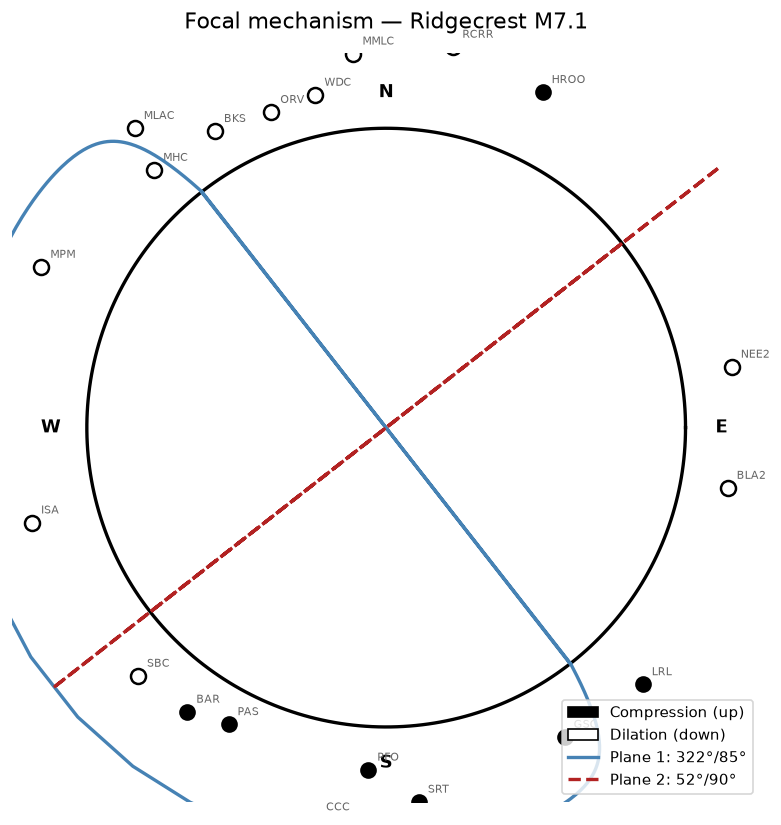

In [9]:
def plot_focal_sphere(polarity_df, strike1=322, dip1=85, rake1=180,
                      strike2=52, dip2=90, rake2=5,
                      title="Focal mechanism — Ridgecrest M7.1"):
    """
    Plot first-motion polarities on a lower-hemisphere equal-area focal sphere,
    with the two nodal planes overlaid.

    Parameters
    ----------
    polarity_df : pd.DataFrame
        Columns: azimuth (deg), takeoff (deg from vertical), polarity (+1/-1).
    strike1, dip1, rake1 : float
        Strike, dip, rake of nodal plane 1 (the primary fault plane).
    strike2, dip2, rake2 : float
        Strike, dip, rake of nodal plane 2 (the auxiliary plane).
    title : str
        Plot title.
    """

    def lower_hem_project(azimuth_deg, takeoff_deg):
        """Lambert equal-area lower-hemisphere projection."""
        az  = np.radians(azimuth_deg)
        toa = np.radians(takeoff_deg)   # from vertical (0 = up)
        # Convert to incidence angle from downward vertical
        inc = np.pi - toa               # takeoff from below
        r   = np.sqrt(2) * np.sin(inc / 2)
        x   = r * np.sin(az)
        y   = r * np.cos(az)
        return x, y

    def nodal_plane_curve(strike_deg, dip_deg, n_pts=200):
        """Trace a nodal plane on the lower-hemisphere projection."""
        strike = np.radians(strike_deg)
        dip    = np.radians(dip_deg)
        phi    = np.linspace(0, np.pi, n_pts)  # along-strike parameter

        # Direction cosines of the pole to the fault plane
        # in (N, E, down) coordinates
        xs, ys = [], []
        for p in phi:
            # A point on the great circle in spherical coords
            az_pt = strike + np.arctan2(
                np.cos(dip) * np.sin(p),
                np.cos(p)
            )
            toa_pt = np.arccos(
                np.clip(-np.sin(dip) * np.sin(p), -1, 1)
            )
            # Only lower hemisphere (toa > pi/2 means going down from source)
            if toa_pt > np.pi / 2:
                toa_pt = np.pi - toa_pt
                az_pt += np.pi
            x, y = lower_hem_project(
                np.degrees(az_pt) % 360,
                np.degrees(toa_pt)
            )
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    fig, ax = plt.subplots(figsize=(7, 7))

    # Outer circle
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), "k", lw=2)
    ax.set_aspect("equal")
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.axis("off")

    # Cardinal labels
    for label, x, y in [("N", 0, 1.12), ("S", 0, -1.12),
                         ("E", 1.12, 0), ("W", -1.12, 0)]:
        ax.text(x, y, label, ha="center", va="center", fontsize=11, fontweight="bold")

    # Plot polarity observations
    for _, row in polarity_df.iterrows():
        x, y = lower_hem_project(row["azimuth"], row["takeoff"])
        if row["polarity"] == 1:
            ax.plot(x, y, "ko", ms=9, zorder=5)
        else:
            ax.plot(x, y, "wo", ms=9, mec="k", mew=1.5, zorder=5)
        ax.text(x + 0.03, y + 0.03, row["station"], fontsize=6.5, color="0.4")

    # Nodal planes
    for strike, dip, color, ls, lbl in [
        (strike1, dip1, "steelblue", "-", f"Plane 1: {strike1}°/{dip1}°"),
        (strike2, dip2, "firebrick", "--", f"Plane 2: {strike2}°/{dip2}°"),
    ]:
        xs, ys = nodal_plane_curve(strike, dip)
        ax.plot(xs, ys, color=color, lw=2, ls=ls, label=lbl, zorder=4)

    # Legend
    comp_patch  = mpatches.Patch(color="black", label="Compression (up)")
    dil_patch   = mpatches.Patch(facecolor="white", edgecolor="black", label="Dilation (down)")
    ax.legend(
        handles=[comp_patch, dil_patch,
                 plt.Line2D([0],[0], color="steelblue", lw=2, label=f"Plane 1: {strike1}°/{dip1}°"),
                 plt.Line2D([0],[0], color="firebrick", lw=2, ls="--", label=f"Plane 2: {strike2}°/{dip2}°")],
        loc="lower right",
        fontsize=9,
    )

    ax.set_title(title, fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()


# Plot with the known Ridgecrest M7.1 nodal planes
# Plane 1: NW-striking right-lateral fault (the main rupture)
# Plane 2: NE-striking left-lateral conjugate (the auxiliary plane)
plot_focal_sphere(
    polarity_data,
    strike1=322, dip1=85, rake1=180,
    strike2=52,  dip2=90, rake2=5,
)


> **Interpret the focal mechanism:**
> 1. Describe the overall pattern of compressional and dilatational quadrants. Does the mechanism look more like a normal fault, reverse fault, or strike-slip fault? How can you tell?
> 2. The two nodal planes divide the focal sphere. Plane 1 strikes NW (322°) and Plane 2 strikes NE (52°). Look at the Ridgecrest map — major mapped faults in the region trend NW–SE. Which nodal plane is most likely the actual fault plane? What additional evidence would you need to confirm this?
> 3. The rake of Plane 1 is ~180° (right-lateral strike-slip). Is this consistent with the static GNSS offsets you measured in Part I? Explain.
> 4. In lecture we discussed the fault plane ambiguity. If you had aftershock locations (which outline the actual fault plane), how would you expect them to be distributed in map view — along the NW or NE trend?
> 5. The M6.4 foreshock two days earlier ruptured on the conjugate NE-striking left-lateral fault (Plane 2 orientation). How does having two conjugate fault orientations in the same stress field make sense mechanically? What does that tell you about the regional stress field orientation?


---
## Synthesis

> **In a short paragraph for each question, integrate what you have learned across all four parts of this lab.**
>
> 1. **Static vs. dynamic:** In Part I you measured a static offset of roughly ___ mm to the east at station P595. In Part IV you determined that the fault is NW-striking and right-lateral. Are these consistent? A right-lateral NW-striking fault should produce displacement in which direction on the east side of the fault? Does your GNSS observation agree?
>
> 2. **Complementarity of datasets:** Complete this table based on your observations:
>
> | Dataset | What it tells you about Ridgecrest M7.1 | What it cannot tell you |
> |---------|----------------------------------------|-------------------------|
> | High-rate GNSS | | |
> | Broadband seismograms | | |
> | Seismic moment calculation | | |
> | Focal mechanism | | |
>
> 3. **Looking ahead:** In Week 4 we will use Green's functions to invert geodetic data for fault slip. Given what you now know about the Ridgecrest fault geometry (strike, dip, rake from the focal mechanism) and fault dimensions and slip (from Part III), describe in plain language what a geodetic inversion would be doing. What are the knowns, what are the unknowns, and what observations constrain them?


---
## Summary

- High-rate GNSS records both **static** (permanent coseismic offset) and **dynamic** (transient wave passage) deformation in a single time series. Static offsets decay with distance; dynamic wave amplitudes also decay but the signal is detectable much farther from the source.
- **P waves** arrive before **S waves** at every station. The S–P time interval increases with epicentral distance and can be used to estimate source distance. Waveform character — dominant frequency, amplitude, pulse shape — changes systematically with distance due to geometric spreading and attenuation.
- **Scalar seismic moment** $M_0 = \mu D A$ directly connects measurable fault properties to earthquake size. **Moment magnitude** $M_w$ is logarithmic in $M_0$ and does not saturate. A factor-of-two change in slip produces a $\sim$0.2 unit change in $M_w$.
- **P-wave first motions** (up = compressional, down = dilatational) constrain the fault geometry. Plotting polarities on the focal sphere and finding two nodal planes gives the **focal mechanism** — strike, dip, and rake — in the same parameterization used for geodetic fault models.
- The **fault plane ambiguity** means seismology alone cannot identify which of the two nodal planes is the actual fault. Aftershock locations, surface rupture mapping, or geodetic surface deformation patterns resolve the ambiguity.
- **Green's functions** are the mathematical bridge between earthquake sources and observed seismograms, and between geodetic observations and fault slip models. The same framework underlies both seismic waveform modeling and the geodetic inversions we will develop in Week 4.

---
**References**

- Liu, C., et al. (2019). Fault geometry and slip distribution of the 2019 Ridgecrest earthquake sequence from joint inversion of strong motion, GPS, and InSAR data. *Geophysical Research Letters*, 46, 18. https://doi.org/10.1029/2019GL084949
- Atterholt, J., et al. (2025). Focal mechanisms of the 2019 Ridgecrest aftershock sequence. *Seismological Research Letters*.
- IRIS/EarthScope Consortium: https://ds.iris.edu
- UNAVCO/EarthScope high-rate GNSS: https://www.unavco.org
- Global CMT Catalog: https://www.globalcmt.org
- Shearer, P. M. (2009). *Introduction to Seismology*, 2nd ed. Cambridge University Press.
